# Intensity Transformations & Filtering Spatial Domain

## Thresholding

In [4]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE) # we should transform grayscale image to b&w in thresholding

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) # cv2 provides thresholding function, we pass the image we wanna threshold
    # then we pass the threshold value, if the pixel intensity higher than 50 -> go to 255, if less -> go to 0
    # we'll get twi two objects, TH value either 255 or , and thres image
    # pixel > threshold -> 255, else pixel < threshold -> 0
    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Threshold value: 0


NameError: name 'cv2_imshow' is not defined

Original Image: 


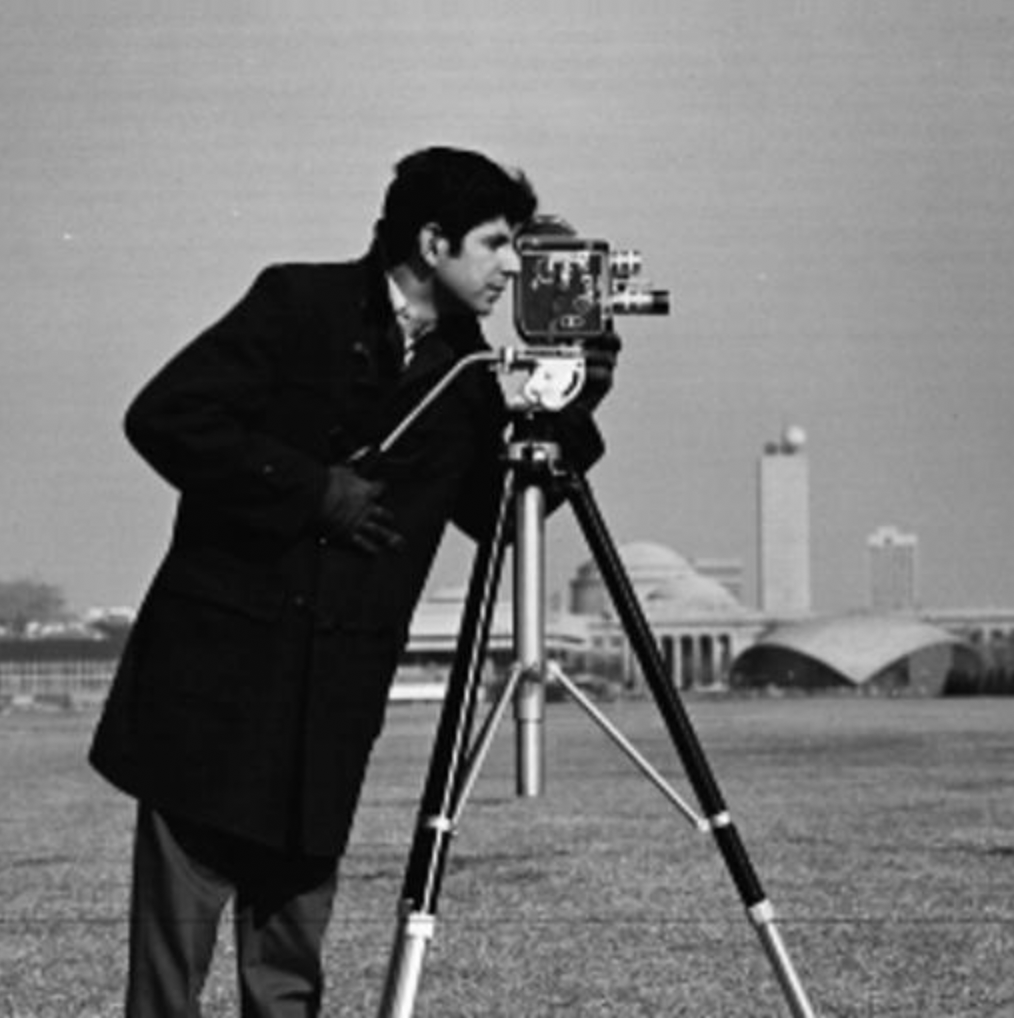

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

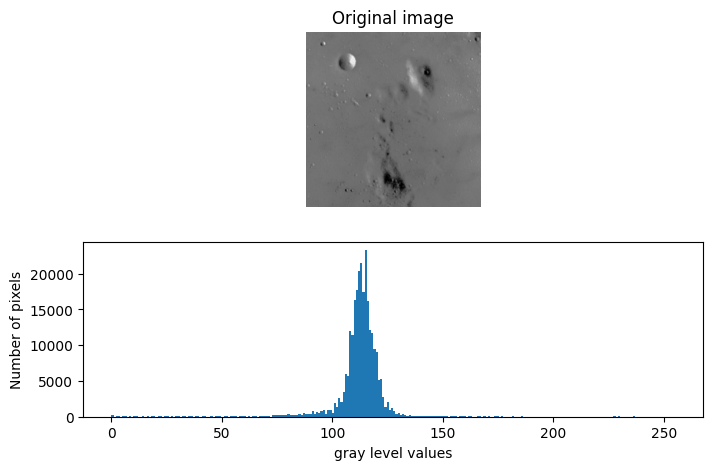

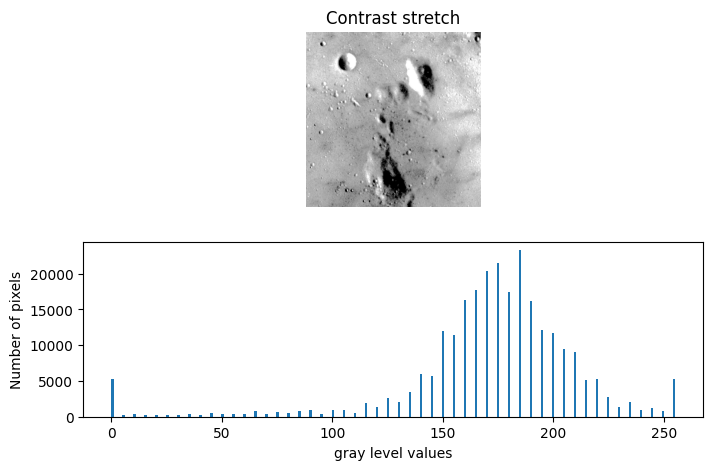

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib # for the histogram
import matplotlib.pyplot as plt
import numpy as np # percentile, used for contrast streching in this lab

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon() # moon is an image in the data collection

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98)) # we choose two percentiles, range 2-98
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98)) # shrink it and strech it 

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) # 2 for rows, 1 column, put the image in position 1 
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2) # add histogram in position 2 
plt.hist(img.flat, bins = 256, range=(0, 255)) # we pass the flattened image bc the histogram acceps the image as 1d array NOT 2d, 256 pixel intensity
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


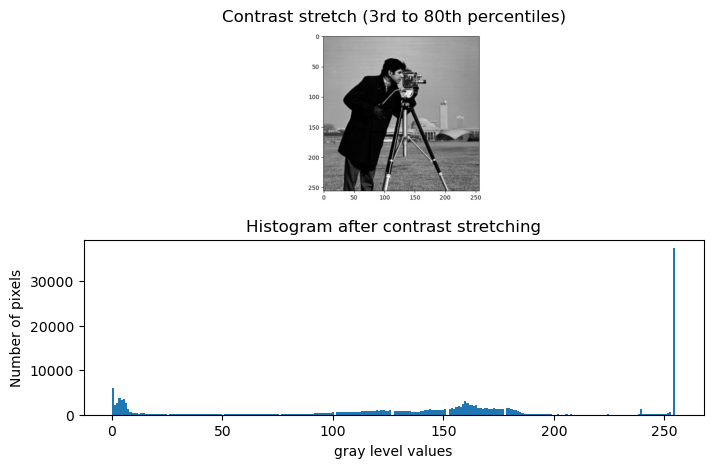

In [8]:
# task 1 
import numpy as np
import cv2 
from skimage import data
from skimage import exposure
import matplotlib # for the histogram
import matplotlib.pyplot as plt
import numpy as np # percentile, used for contrast streching in this lab

p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd to 80th percentiles)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after contrast stretching')
plt.show()

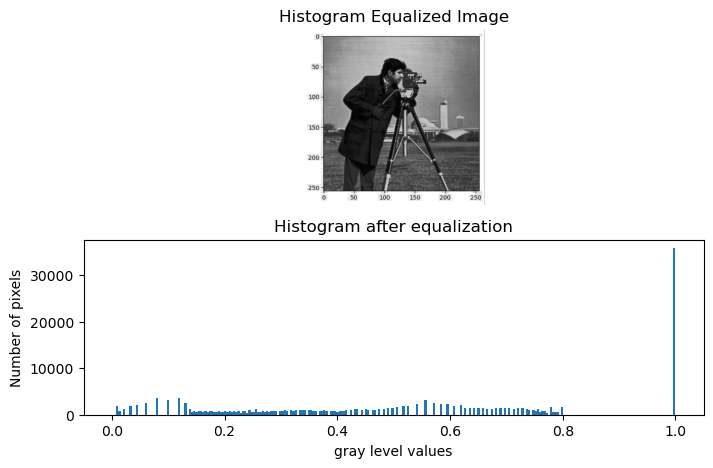

In [9]:
# task 2 
img_equalized = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')

fig.add_subplot(2, 1, 2)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after equalization')
plt.show()

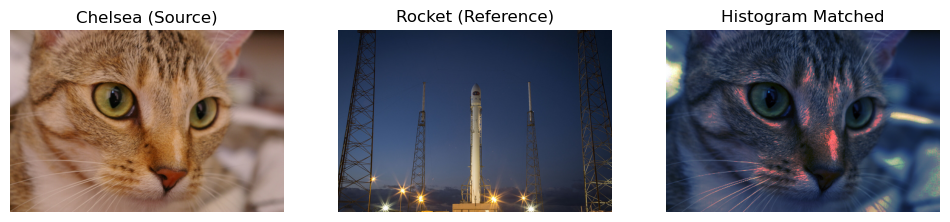

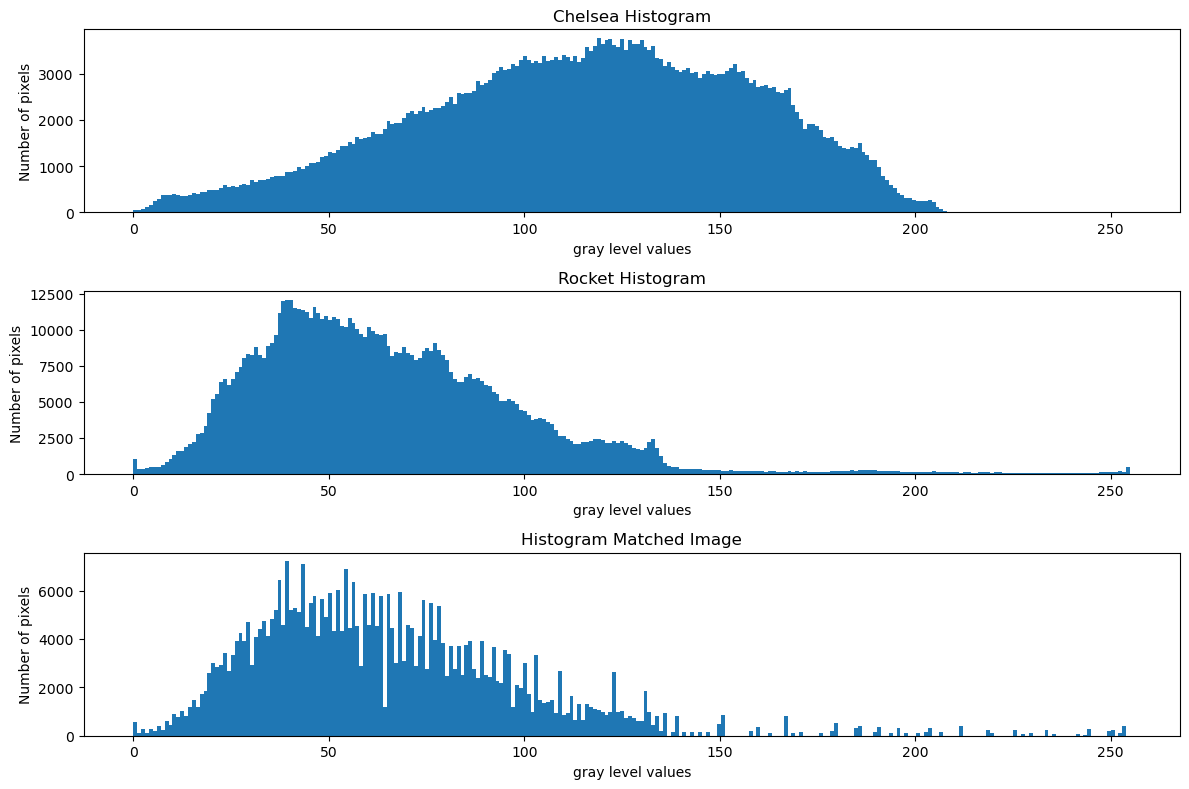

In [10]:
# task 3
from skimage import data, exposure

reference = data.rocket()
source = data.chelsea()
matched = exposure.match_histograms(source, reference, channel_axis=-1)

# Display the source, reference, and matched images
fig = plt.figure(figsize=(12, 4))
fig.add_subplot(1, 3, 1)
plt.imshow(source)
plt.axis('off')
plt.title('Chelsea (Source)')

fig.add_subplot(1, 3, 2)
plt.imshow(reference)
plt.axis('off')
plt.title('Rocket (Reference)')

fig.add_subplot(1, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched')
plt.show()

# Display the histograms
fig = plt.figure(figsize=(12, 8))
fig.add_subplot(3, 1, 1)
plt.hist(source.ravel(), bins=256, range=(0, 255))
plt.title('Chelsea Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

fig.add_subplot(3, 1, 2)
plt.hist(reference.ravel(), bins=256, range=(0, 255))
plt.title('Rocket Histogram')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

fig.add_subplot(3, 1, 3)
plt.hist(matched.ravel(), bins=256, range=(0, 255))
plt.title('Histogram Matched Image')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()